# Swin-T + MIL Attention Pooling
## Brain Tumor Sub-Region Classification – BraTS2020

**Task:** Patient-level multi-label binary classification → `[NCR, ED, ET]`  
**Input:** 155 MRI slices × 4 channels (T1, T1ce, T2, FLAIR) per patient  

---

In [1]:
!pip install timm h5py scikit-learn --quiet
import torch
print(f'PyTorch: {torch.__version__}')
print(f'CUDA: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

PyTorch: 2.10.0+cu128
CUDA: True
GPU: NVIDIA A100-SXM4-80GB
VRAM: 85.1 GB


## Kaggle Dataset Download


In [2]:
from google.colab import files
files.upload()
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d awsaf49/brats2020-training-data -p /content/brats2020 --unzip
print('Download complete!')

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/awsaf49/brats2020-training-data
License(s): CC0-1.0
100% 6.76G/6.76G [06:01<00:00, 20.1MB/s]

Download complete!


In [3]:
import os
DATA_ROOT = '/content/brats2020'
for root, dirs, flist in os.walk(DATA_ROOT):
    level = root.replace(DATA_ROOT, '').count(os.sep)
    indent = '  ' * level
    print(f'{indent}{os.path.basename(root)}/')
    if level < 2:
        sub = '  ' * (level + 1)
        for f in flist[:5]:
            print(f'{sub}{f}')
        if len(flist) > 5:
            print(f'{sub}... and {len(flist)-5} more')

brats2020/
  BraTS20 Training Metadata.csv
  BraTS2020_training_data/
    content/
      data/


## Imports & Configuration

In [4]:
import os, random, time, glob, warnings
import numpy as np
import pandas as pd
import h5py
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF
import timm
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score, precision_score, recall_score, accuracy_score
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: cuda


In [5]:
CFG = {
    'data_root':       '/content/brats2020',
    'csv_path':        '/content/brats2020/BraTS20 Training Metadata.csv',
    'h5_dir':          '/content/brats2020',
    'img_size':        224,
    'num_slices':      155,
    'num_channels':    4,
    'num_classes':     3,
    'backbone':        'swin_tiny_patch4_window7_224',
    'embed_dim':       768,
    'mil_hidden':      256,
    'epochs':          30,
    'batch_size':      4,
    'lr_backbone':     1e-5,
    'lr_head':         1e-4,
    'weight_decay':    1e-4,
    'dropout':         0.3,
    'patience':        7,
    'train_frac':      0.70,
    'val_frac':        0.15,
    'test_frac':       0.15,
    'num_workers':     4,
    'pin_memory':      True,
    'mixed_precision': True,
    'checkpoint_path': '/content/swin_mil_best.pth',
}
print('Config ready.')

Config ready.


##Data Loading & Label Construction

In [6]:
df = pd.read_csv(CFG['csv_path'])
print(f'CSV shape: {df.shape}')
print(df.head())
print('Columns:', df.columns.tolist())

CSV shape: (57195, 8)
                                          slice_path  target  volume  slice  \
0  ../input/brats2020-training-data/BraTS2020_tra...       0      41      0   
1  ../input/brats2020-training-data/BraTS2020_tra...       0      41      1   
2  ../input/brats2020-training-data/BraTS2020_tra...       0      41      2   
3  ../input/brats2020-training-data/BraTS2020_tra...       0      41      3   
4  ../input/brats2020-training-data/BraTS2020_tra...       0      41      4   

   label0_pxl_cnt  label1_pxl_cnt  label2_pxl_cnt  background_ratio  
0               0               0               0               1.0  
1               0               0               0               1.0  
2               0               0               0               1.0  
3               0               0               0               1.0  
4               0               0               0               1.0  
Columns: ['slice_path', 'target', 'volume', 'slice', 'label0_pxl_cnt', 'label1_pxl_

In [7]:
ID_COL  = 'volume'
NCR_COL = 'label0_pxl_cnt'  # NCR/NET pixel count
ED_COL  = 'label1_pxl_cnt'  # Peritumoral Edema pixel count
ET_COL  = 'label2_pxl_cnt'  # Enhancing Tumour pixel count

# Verify columns
for col in [NCR_COL, ED_COL, ET_COL]:
    assert col in df.columns, f'Column {col!r} not found in CSV. Available: {df.columns.tolist()}'
print('Columns verified')

patient_df = df.groupby(ID_COL).agg(
    ncr_total = (NCR_COL, 'sum'),
    ed_total  = (ED_COL,  'sum'),
    et_total  = (ET_COL,  'sum'),
).reset_index()

patient_df['NCR'] = (patient_df['ncr_total'] > 0).astype(int)
patient_df['ED']  = (patient_df['ed_total']  > 0).astype(int)
patient_df['ET']  = (patient_df['et_total']  > 0).astype(int)

patient_df = patient_df[[ID_COL, 'NCR', 'ED', 'ET']].rename(columns={ID_COL: 'patient_id'})

print(f'Patients: {len(patient_df)}')
print(patient_df.head(10))
print('\nLabel totals (patient-level):')
print(patient_df[['NCR', 'ED', 'ET']].sum())
print('\nPatients with no label at all (all zeros):',
      (patient_df[['NCR','ED','ET']].sum(axis=1) == 0).sum())
print('\nCo-occurrence matrix (how many patients have each combo):')
print(patient_df.groupby(['NCR','ED','ET']).size().reset_index(name='count'))


Columns verified
Patients: 369
   patient_id  NCR  ED  ET
0           1    1   1   1
1           2    1   1   1
2           3    1   1   1
3           4    1   1   1
4           5    1   1   1
5           6    1   1   1
6           7    1   1   1
7           8    1   1   1
8           9    1   1   1
9          10    1   1   1

Label totals (patient-level):
NCR    368
ED     368
ET     342
dtype: int64

Patients with no label at all (all zeros): 0

Co-occurrence matrix (how many patients have each combo):
   NCR  ED  ET  count
0    0   1   1      1
1    1   0   1      1
2    1   1   0     27
3    1   1   1    340


In [8]:
import re

df = pd.read_csv(CFG['csv_path'])

NCR_COL = 'label0_pxl_cnt'
ED_COL  = 'label1_pxl_cnt'
ET_COL  = 'label2_pxl_cnt'
ID_COL  = 'volume'

patient_df = df.groupby(ID_COL).agg(
    ncr_total = (NCR_COL, 'sum'),
    ed_total  = (ED_COL,  'sum'),
    et_total  = (ET_COL,  'sum'),
).reset_index()

patient_df['NCR'] = (patient_df['ncr_total'] > 0).astype(int)
patient_df['ED']  = (patient_df['ed_total']  > 0).astype(int)
patient_df['ET']  = (patient_df['et_total']  > 0).astype(int)
patient_df = patient_df[[ID_COL, 'NCR', 'ED', 'ET']].rename(columns={ID_COL: 'patient_id'})
print(f'patient_df: {len(patient_df)} patients')
print(f'patient_id dtype: {patient_df["patient_id"].dtype}')
print(f'Sample IDs: {patient_df["patient_id"].tolist()[:10]}')

h5_files = glob.glob(os.path.join(CFG['h5_dir'], '**', '*.h5'), recursive=True)
print(f'\nFound {len(h5_files)} h5 files')

h5_map = {}
for fpath in h5_files:
    m = re.match(r'volume_(\d+)_slice_(\d+)\.h5', os.path.basename(fpath))
    if m:
        vid = int(m.group(1))
        h5_map.setdefault(vid, []).append(fpath)

for vid in h5_map:
    h5_map[vid].sort(key=lambda p: int(re.search(r'slice_(\d+)', p).group(1)))

print(f'Unique volumes in h5_map: {len(h5_map)}')
print(f'Sample h5_map keys: {sorted(h5_map.keys())[:10]}')

pid_type   = type(patient_df['patient_id'].iloc[0])
h5key_type = type(list(h5_map.keys())[0])
print(f'\npatient_id type: {pid_type}, h5_map key type: {h5key_type}')

patient_df['patient_id'] = patient_df['patient_id'].astype(int)
h5_map = {int(k): v for k, v in h5_map.items()}

overlap = set(patient_df['patient_id'].tolist()) & set(h5_map.keys())
print(f'Overlapping IDs: {len(overlap)}')

patient_df = patient_df[patient_df['patient_id'].isin(h5_map)].reset_index(drop=True)
patient_df['h5_paths'] = patient_df['patient_id'].map(h5_map)
print(f'Matched: {len(patient_df)} patients')
print(f'Slices per patient (first 5): {patient_df["h5_paths"].apply(len).head().tolist()}')

sample_path = patient_df['h5_paths'].iloc[0][0]
print(f'\nSample path: {sample_path}')
with h5py.File(sample_path, 'r') as f:
    print('H5 keys:', list(f.keys()))
    for k in f.keys():
        print(f'  {k}: shape={f[k].shape}, dtype={f[k].dtype}')


patient_df: 369 patients
patient_id dtype: int64
Sample IDs: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

Found 57195 h5 files
Unique volumes in h5_map: 369
Sample h5_map keys: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

patient_id type: <class 'numpy.int64'>, h5_map key type: <class 'int'>
Overlapping IDs: 369
Matched: 369 patients
Slices per patient (first 5): [155, 155, 155, 155, 155]

Sample path: /content/brats2020/BraTS2020_training_data/content/data/volume_1_slice_0.h5
H5 keys: ['image', 'mask']
  image: shape=(240, 240, 4), dtype=float64
  mask: shape=(240, 240, 3), dtype=uint8


In [9]:
#Train / Val / Test split
train_val_df, test_df = train_test_split(patient_df, test_size=CFG['test_frac'], random_state=SEED, shuffle=True)
val_size = CFG['val_frac'] / (CFG['train_frac'] + CFG['val_frac'])
train_df, val_df = train_test_split(train_val_df, test_size=val_size, random_state=SEED, shuffle=True)

print(f'Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}')
for name, split in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    print(f'  {name}: NCR={split["NCR"].sum()}, ED={split["ED"].sum()}, ET={split["ET"].sum()}')

Train: 257 | Val: 56 | Test: 56
  Train: NCR=256, ED=256, ET=237
  Val: NCR=56, ED=56, ET=52
  Test: NCR=56, ED=56, ET=53


##Dataset Class

In [10]:
# Dataset
class BraTS2020Dataset(Dataset):
    def __init__(self, df, img_size=224, num_slices=155, augment=False):
        self.df         = df.reset_index(drop=True)
        self.img_size   = img_size
        self.num_slices = num_slices
        self.augment    = augment

    def __len__(self):
        return len(self.df)

    def _load_slice(self, path):
        with h5py.File(path, 'r') as f:
            img = f['image'][()]
        img = img.transpose(2, 0, 1).astype(np.float32)
        # Per-channel min-max normalise
        for c in range(img.shape[0]):
            mn, mx = img[c].min(), img[c].max()
            if mx > mn:
                img[c] = (img[c] - mn) / (mx - mn)
        t = torch.from_numpy(img)
        t = F.interpolate(t.unsqueeze(0),
                          size=(self.img_size, self.img_size),
                          mode='bilinear', align_corners=False).squeeze(0)
        return t

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        label = torch.tensor([row['NCR'], row['ED'], row['ET']], dtype=torch.float32)
        paths = row['h5_paths']

        slices = []
        for i in range(self.num_slices):
            sl = self._load_slice(paths[i])
            if self.augment:
                if random.random() > 0.5: sl = TF.hflip(sl)
                if random.random() > 0.5: sl = TF.vflip(sl)
            slices.append(sl)

        return torch.stack(slices, dim=0), label

ds_tmp = BraTS2020Dataset(patient_df.head(1))
vol, lbl = ds_tmp[0]
print(f'Volume shape : {vol.shape}')
print(f'Label        : {lbl}')
print(f'Value range  : [{vol.min():.3f}, {vol.max():.3f}]')

Volume shape : torch.Size([155, 4, 224, 224])
Label        : tensor([1., 1., 1.])
Value range  : [0.000, 1.000]


In [11]:
# DataLoaders
train_dataset = BraTS2020Dataset(train_df, augment=True)
val_dataset   = BraTS2020Dataset(val_df,   augment=False)
test_dataset  = BraTS2020Dataset(test_df,  augment=False)

train_loader = DataLoader(train_dataset, batch_size=CFG['batch_size'], shuffle=True,
                          num_workers=CFG['num_workers'], pin_memory=CFG['pin_memory'])
val_loader   = DataLoader(val_dataset,   batch_size=CFG['batch_size'], shuffle=False,
                          num_workers=CFG['num_workers'], pin_memory=CFG['pin_memory'])
test_loader  = DataLoader(test_dataset,  batch_size=CFG['batch_size'], shuffle=False,
                          num_workers=CFG['num_workers'], pin_memory=CFG['pin_memory'])

print(f'Batches Train: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}')

Batches Train: 65 | Val: 14 | Test: 14


## Model: Swin-T + MIL Attention Pooling

In [12]:
class MILAttentionPooling(nn.Module):

    def __init__(self, embed_dim, hidden_dim, dropout=0.0):
        super().__init__()
        self.attn = nn.Sequential(
            nn.Linear(embed_dim, hidden_dim),
            nn.Tanh(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, H):
        # H: (B, S, D)
        A = self.attn(H)
        A = torch.softmax(A, dim=1)
        z = (A * H).sum(dim=1)
        return z, A.squeeze(-1)


class SwinMILClassifier(nn.Module):
    def __init__(self, embed_dim=768, mil_hidden=256, num_classes=3, dropout=0.3):
        super().__init__()

        backbone = timm.create_model(
            'swin_tiny_patch4_window7_224',
            pretrained=True,
            num_classes=0,
            global_pool='avg',
        )

        old = backbone.patch_embed.proj
        new = nn.Conv2d(4, old.out_channels, old.kernel_size,
                        old.stride, old.padding,
                        bias=(old.bias is not None))
        with torch.no_grad():
            new.weight[:, :3] = old.weight
            new.weight[:, 3:] = old.weight.mean(dim=1, keepdim=True)
            if old.bias is not None:
                new.bias = old.bias
        backbone.patch_embed.proj = new
        self.backbone = backbone

        self.mil = MILAttentionPooling(embed_dim, mil_hidden, dropout=dropout)

        self.head = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Dropout(dropout),
            nn.Linear(embed_dim, 128),
            nn.GELU(),
            nn.Dropout(dropout / 2),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        B, S, C, H, W = x.shape
        h = self.backbone(x.view(B * S, C, H, W))
        H_seq = h.view(B, S, -1)
        z, attn_w = self.mil(H_seq)
        return self.head(z), attn_w


model = SwinMILClassifier(
    embed_dim=CFG['embed_dim'],
    mil_hidden=CFG['mil_hidden'],
    num_classes=CFG['num_classes'],
    dropout=CFG['dropout'],
).to(DEVICE)

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total params:     {total:,}')
print(f'Trainable params: {trainable:,}')


with torch.no_grad():
    dummy = torch.randn(2, 10, 4, 224, 224).to(DEVICE)
    lg, aw = model(dummy)
print(f'Logits: {lg.shape} | Attention: {aw.shape}')

model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

Total params:     27,818,366
Trainable params: 27,818,366
Logits: torch.Size([2, 3]) | Attention: torch.Size([2, 10])


##Loss, Optimizer & Scheduler

In [13]:
n = len(train_df)
pos_weights = torch.tensor([
    (n - train_df['NCR'].sum()) / (train_df['NCR'].sum() + 1e-6),
    (n - train_df['ED'].sum())  / (train_df['ED'].sum()  + 1e-6),
    (n - train_df['ET'].sum())  / (train_df['ET'].sum()  + 1e-6),
], dtype=torch.float32).to(DEVICE)
print(f'pos_weights (NCR, ED, ET): {pos_weights.cpu().tolist()}')

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weights)

optimizer = torch.optim.AdamW([
    {'params': model.backbone.parameters(), 'lr': CFG['lr_backbone']},
    {'params': list(model.mil.parameters()) + list(model.head.parameters()),
     'lr': CFG['lr_head']},
], weight_decay=CFG['weight_decay'])

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=CFG['epochs'], eta_min=1e-7
)
scaler = torch.cuda.amp.GradScaler(enabled=CFG['mixed_precision'])

pos_weights (NCR, ED, ET): [0.00390625, 0.00390625, 0.08438818901777267]


## Training Loop

In [14]:
def train_one_epoch(model, loader, optimizer, criterion, scaler, device):
    model.train()
    total_loss = 0.0
    all_preds, all_labels = [], []

    for i, (vols, labels) in enumerate(loader):
        vols   = vols.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        optimizer.zero_grad()

        with torch.cuda.amp.autocast(enabled=CFG['mixed_precision']):
            logits, _ = model(vols)
            loss = criterion(logits, labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
        preds = (torch.sigmoid(logits) >= 0.5).int().cpu().numpy()
        all_preds.append(preds)
        all_labels.append(labels.int().cpu().numpy())

        if (i + 1) % 10 == 0:
            print(f'  Batch [{i+1}/{len(loader)}] loss={loss.item():.4f}')

    all_preds  = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)
    return total_loss / len(loader), f1_score(all_labels, all_preds, average='macro', zero_division=0)


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_preds, all_labels = [], []

    for vols, labels in loader:
        vols   = vols.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        with torch.cuda.amp.autocast(enabled=CFG['mixed_precision']):
            logits, _ = model(vols)
            loss = criterion(logits, labels)
        total_loss += loss.item()
        preds = (torch.sigmoid(logits) >= 0.5).int().cpu().numpy()
        all_preds.append(preds)
        all_labels.append(labels.int().cpu().numpy())

    all_preds  = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)
    return total_loss/len(loader), f1_score(all_labels, all_preds, average='macro', zero_division=0), all_preds, all_labels

print('Training functions ready.')

Training functions ready.


In [15]:
history = {'train_loss':[], 'val_loss':[], 'train_f1':[], 'val_f1':[]}
best_val_f1 = -1.0
patience_counter = 0

print('=' * 60)
print(f'Training for {CFG["epochs"]} epochs | device={DEVICE} | AMP={CFG["mixed_precision"]}')
print('=' * 60)

for epoch in range(1, CFG['epochs'] + 1):
    t0 = time.time()
    print(f'\n-- Epoch {epoch}/{CFG["epochs"]} --')

    tr_loss, tr_f1 = train_one_epoch(model, train_loader, optimizer, criterion, scaler, DEVICE)
    vl_loss, vl_f1, _, _ = evaluate(model, val_loader, criterion, DEVICE)
    scheduler.step()

    elapsed = time.time() - t0
    print(f'  Train  loss={tr_loss:.4f}  f1={tr_f1:.4f}')
    print(f'  Val    loss={vl_loss:.4f}  f1={vl_f1:.4f}')
    print(f'  LR backbone={optimizer.param_groups[0]["lr"]:.2e}  head={optimizer.param_groups[1]["lr"]:.2e}')
    print(f'  Time: {elapsed:.1f}s')

    history['train_loss'].append(tr_loss); history['val_loss'].append(vl_loss)
    history['train_f1'].append(tr_f1);    history['val_f1'].append(vl_f1)

    if vl_f1 > best_val_f1:
        best_val_f1 = vl_f1
        patience_counter = 0
        torch.save({'epoch': epoch,
                    'model_state_dict': model.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    'val_f1': best_val_f1}, CFG['checkpoint_path'])
        print(f'  [SAVED] best model (val_f1={best_val_f1:.4f})')
    else:
        patience_counter += 1
        print(f'  No improvement. Patience {patience_counter}/{CFG["patience"]}')
        if patience_counter >= CFG['patience']:
            print(f'Early stopping at epoch {epoch}.')
            break

print(f'\nDone. Best Val F1: {best_val_f1:.4f}')

Training for 30 epochs | device=cuda | AMP=True

-- Epoch 1/30 --
  Batch [10/65] loss=0.0123
  Batch [20/65] loss=0.0037
  Batch [30/65] loss=0.0059
  Batch [40/65] loss=0.0830
  Batch [50/65] loss=0.0157
  Batch [60/65] loss=0.0179
  Train  loss=0.0464  f1=0.9146
  Val    loss=0.0352  f1=0.9844
  LR backbone=9.97e-06  head=9.97e-05
  Time: 126.9s
  [SAVED] best model (val_f1=0.9844)

-- Epoch 2/30 --
  Batch [10/65] loss=0.0192
  Batch [20/65] loss=0.0102
  Batch [30/65] loss=0.0091
  Batch [40/65] loss=0.0114
  Batch [50/65] loss=0.0094
  Batch [60/65] loss=0.1222
  Train  loss=0.0427  f1=0.9584
  Val    loss=0.0336  f1=0.9024
  LR backbone=9.89e-06  head=9.89e-05
  Time: 126.8s
  No improvement. Patience 1/7

-- Epoch 3/30 --
  Batch [10/65] loss=0.0913
  Batch [20/65] loss=0.0174
  Batch [30/65] loss=0.1205
  Batch [40/65] loss=0.0118
  Batch [50/65] loss=0.0073
  Batch [60/65] loss=0.0055
  Train  loss=0.0352  f1=0.9345
  Val    loss=0.0423  f1=0.9811
  LR backbone=9.76e-06  head

## Training Curves

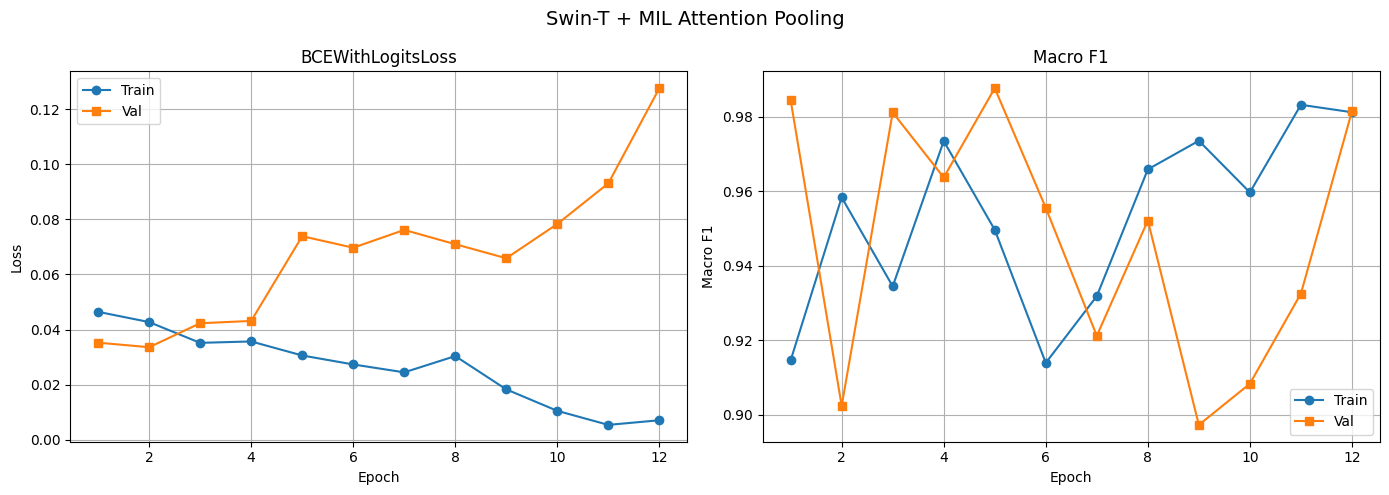

In [16]:
epochs_ran = len(history['train_loss'])
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(range(1, epochs_ran+1), history['train_loss'], 'o-', label='Train')
ax1.plot(range(1, epochs_ran+1), history['val_loss'],   's-', label='Val')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.set_title('BCEWithLogitsLoss'); ax1.legend(); ax1.grid(True)

ax2.plot(range(1, epochs_ran+1), history['train_f1'], 'o-', label='Train')
ax2.plot(range(1, epochs_ran+1), history['val_f1'],   's-', label='Val')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Macro F1')
ax2.set_title('Macro F1'); ax2.legend(); ax2.grid(True)

plt.suptitle('Swin-T + MIL Attention Pooling', fontsize=14)
plt.tight_layout()
plt.savefig('/content/training_curves.png', dpi=150)
plt.show()

##Test Set Evaluation

In [17]:
ckpt = torch.load(CFG['checkpoint_path'], map_location=DEVICE)
model.load_state_dict(ckpt['model_state_dict'])
print(f'Loaded best model from epoch {ckpt["epoch"]} (val_f1={ckpt["val_f1"]:.4f})')

test_loss, test_f1, test_preds, test_labels = evaluate(model, test_loader, criterion, DEVICE)
print(f'Test Loss: {test_loss:.4f}  |  Test Macro F1: {test_f1:.4f}')
print()
print(classification_report(test_labels, test_preds,
                             target_names=['NCR','ED','ET'], digits=4, zero_division=0))

Loaded best model from epoch 5 (val_f1=0.9877)
Test Loss: 0.0556  |  Test Macro F1: 0.9908

              precision    recall  f1-score   support

         NCR     1.0000    1.0000    1.0000        56
          ED     1.0000    1.0000    1.0000        56
          ET     0.9464    1.0000    0.9725        53

   micro avg     0.9821    1.0000    0.9910       165
   macro avg     0.9821    1.0000    0.9908       165
weighted avg     0.9828    1.0000    0.9912       165
 samples avg     0.9821    1.0000    0.9893       165



## MIL Attention Visualization



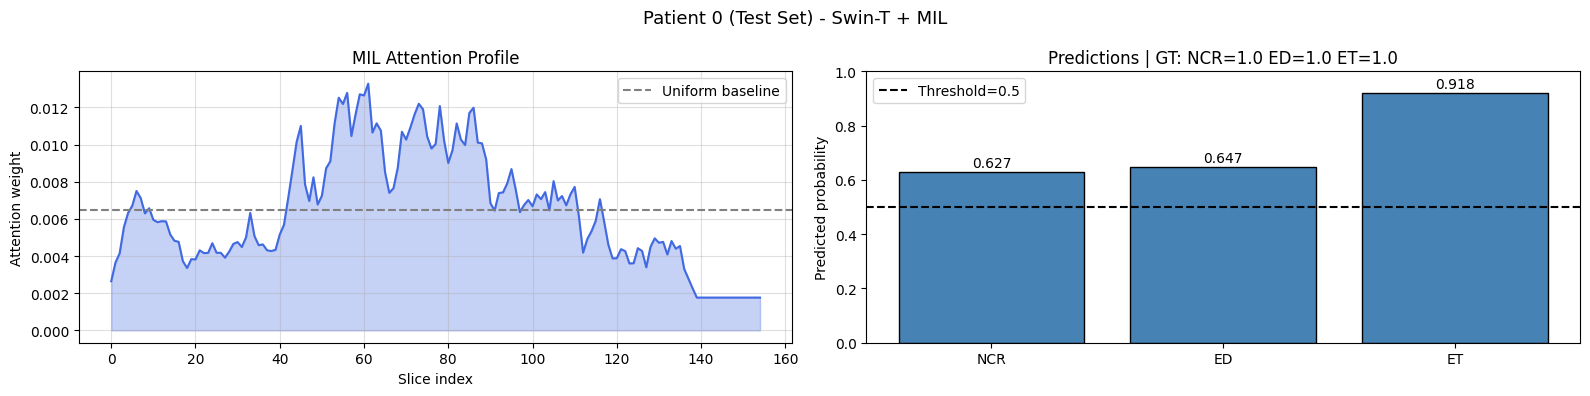

In [18]:
@torch.no_grad()
def get_attention(model, dataset, idx, device):
    model.eval()
    vol, lbl = dataset[idx]
    vol = vol.unsqueeze(0).to(device)
    with torch.cuda.amp.autocast(enabled=CFG['mixed_precision']):
        logits, attn_w = model(vol)
    return torch.sigmoid(logits).squeeze().cpu().numpy(), attn_w.squeeze().cpu().numpy(), lbl.numpy()


probs, attn, gt = get_attention(model, test_dataset, 0, DEVICE)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4))

ax1.plot(attn, color='royalblue', linewidth=1.5)
ax1.fill_between(range(len(attn)), attn, alpha=0.3, color='royalblue')
ax1.axhline(1/len(attn), color='gray', linestyle='--', label='Uniform baseline')
ax1.set_xlabel('Slice index'); ax1.set_ylabel('Attention weight')
ax1.set_title('MIL Attention Profile'); ax1.legend(); ax1.grid(True, alpha=0.4)

colors = ['steelblue' if p >= 0.5 else 'salmon' for p in probs]
bars = ax2.bar(['NCR','ED','ET'], probs, color=colors, edgecolor='black')
ax2.axhline(0.5, color='black', linestyle='--', label='Threshold=0.5')
ax2.set_ylim(0, 1); ax2.set_ylabel('Predicted probability')
ax2.set_title(f'Predictions | GT: NCR={gt[0]} ED={gt[1]} ET={gt[2]}')
for b, p in zip(bars, probs):
    ax2.text(b.get_x() + b.get_width()/2, p + 0.02, f'{p:.3f}', ha='center')
ax2.legend()

plt.suptitle('Patient 0 (Test Set) - Swin-T + MIL', fontsize=13)
plt.tight_layout()
plt.savefig('/content/attention_viz.png', dpi=150)
plt.show()

##Results

## JSON Results Export

In [27]:
## JSON Results Export

import json
import numpy as np
from sklearn.metrics import (
    roc_auc_score, log_loss, accuracy_score,
    precision_score, recall_score, f1_score
)

CLASS_NAMES = ['NCR', 'ED', 'ET']

ckpt = torch.load(CFG['checkpoint_path'], map_location=DEVICE)
model.load_state_dict(ckpt['model_state_dict'])
print(f'Loaded best model from epoch {ckpt["epoch"]} (val_f1={ckpt["val_f1"]:.4f})')

THRESHOLDS = {'NCR': 0.5, 'ED': 0.5, 'ET': 0.5}
print(f'Using thresholds: {THRESHOLDS}')

model.eval()
all_probs_raw, all_labels_raw = [], []
with torch.no_grad():
    for vols, labels in test_loader:
        vols = vols.to(DEVICE, non_blocking=True)
        with torch.cuda.amp.autocast(enabled=CFG['mixed_precision']):
            logits, _ = model(vols)
        probs = torch.sigmoid(logits).cpu().numpy()
        for p, l in zip(probs, labels.numpy()):
            all_probs_raw.append(p.tolist())
            all_labels_raw.append(l.tolist())

all_probs_np  = np.array(all_probs_raw)
all_labels_np = np.array(all_labels_raw)

all_preds_np = np.zeros_like(all_probs_np, dtype=int)
for i, cls in enumerate(CLASS_NAMES):
    all_preds_np[:, i] = (all_probs_np[:, i] >= THRESHOLDS[cls]).astype(int)

overall_acc     = accuracy_score(all_labels_np.flatten(), all_preds_np.flatten())
macro_f1        = float(f1_score(all_labels_np,        all_preds_np, average='macro', zero_division=0))
macro_precision = float(precision_score(all_labels_np, all_preds_np, average='macro', zero_division=0))
macro_recall    = float(recall_score(all_labels_np,    all_preds_np, average='macro', zero_division=0))

auroc_scores = {}
for i, cls in enumerate(CLASS_NAMES):
    try:
        score = roc_auc_score(all_labels_np[:, i], all_probs_np[:, i])
    except ValueError:
        score = float('nan')
    auroc_scores[cls] = score
    tag = f'{score:.4f}' if not np.isnan(score) else 'N/A (only 1 class in test)'
    print(f'  AUROC {cls}: {tag}')
macro_auroc = float(np.nanmean(list(auroc_scores.values())))

logloss_scores = {}
for i, cls in enumerate(CLASS_NAMES):
    try:
        ll = log_loss(all_labels_np[:, i], all_probs_np[:, i], labels=[0, 1])
        logloss_scores[cls] = ll
        print(f'  LogLoss {cls}: {ll:.4f}')
    except Exception:
        logloss_scores[cls] = float('nan')
        print(f'  LogLoss {cls}: N/A')
mean_log_loss = float(np.nanmean(list(logloss_scores.values())))

per_class = {}
for i, cls in enumerate(CLASS_NAMES):
    per_class[cls] = {
        'precision': float(precision_score(all_labels_np[:, i], all_preds_np[:, i], zero_division=0)),
        'recall':    float(recall_score(all_labels_np[:, i],    all_preds_np[:, i], zero_division=0)),
        'f1':        float(f1_score(all_labels_np[:, i],        all_preds_np[:, i], zero_division=0)),
    }
    p = per_class[cls]
    print(f'  {cls} -> P:{p["precision"]:.3f}  R:{p["recall"]:.3f}  F1:{p["f1"]:.3f}')

results = {
    'model':           'Swin-T + MIL Attention Pooling',
    'thresholds':      THRESHOLDS,
    'accuracy':        float(overall_acc),
    'macro_precision': macro_precision,
    'macro_recall':    macro_recall,
    'macro_f1':        macro_f1,
    'auroc':           {cls: (float(v) if not np.isnan(v) else None) for cls, v in auroc_scores.items()},
    'macro_auroc':     macro_auroc,
    'log_loss':        {cls: (float(v) if not np.isnan(v) else None) for cls, v in logloss_scores.items()},
    'mean_log_loss':   mean_log_loss,
    'all_probs':       all_probs_raw,
    'all_preds':       all_preds_np.tolist(),
    'all_labels':      all_labels_raw,
    'per_class':       per_class,
}

RESULTS_PATH = '/content/swin_mil_results.json'
with open(RESULTS_PATH, 'w') as f:
    json.dump(results, f, indent=2)

print(f'\n Results saved to: {RESULTS_PATH}')
print('\nFINAL SUMMARY:')
print(f'  Accuracy:        {results["accuracy"]:.4f}')
print(f'  Macro Precision: {results["macro_precision"]:.4f}')
print(f'  Macro Recall:    {results["macro_recall"]:.4f}')
print(f'  Macro F1:        {results["macro_f1"]:.4f}')
print(f'  Macro AUROC:     {results["macro_auroc"]:.4f}')
print(f'  Mean LogLoss:    {results["mean_log_loss"]:.4f}')

from google.colab import files
files.download(RESULTS_PATH)
files.download('/content/swin_mil_best.pth')


Loaded best model from epoch 5 (val_f1=0.9877)
Using thresholds: {'NCR': 0.5, 'ED': 0.5, 'ET': 0.5}
  AUROC NCR: N/A (only 1 class in test)
  AUROC ED: N/A (only 1 class in test)
  AUROC ET: 0.6981
  LogLoss NCR: 0.4322
  LogLoss ED: 0.2595
  LogLoss ET: 0.2036
  NCR -> P:1.000  R:1.000  F1:1.000
  ED -> P:1.000  R:1.000  F1:1.000
  ET -> P:0.946  R:1.000  F1:0.972

 Results saved to: /content/swin_mil_results.json

FINAL SUMMARY:
  Accuracy:        0.9821
  Macro Precision: 0.9821
  Macro Recall:    1.0000
  Macro F1:        0.9908
  Macro AUROC:     0.6981
  Mean LogLoss:    0.2984


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>